In [1]:
import json
import pandas as pd
import numpy as np
from Bio.SeqUtils import molecular_weight
from math import log10
import re

In [9]:
# 定义替换映射
species_mapping = {
    'Propionibacterium acnes': 'Cutibacterium acnes',
    'Candida krusei': 'Pichia kudriavzevii',
    'Candida glabrata': 'Nakaseomyces glabratus',
    'Lactobacillus salivarius': 'Ligilactobacillus salivarius'
}

### 待合并的数据集有：APD6，CAMP3， DBAASP，GRAMPA


* APD6，CAMP3， DBAASP 列MIC_Value(ug/ml) 转换列为log_MIC_Value(uM)
* 每个数据集先去重，清洗AMP序列
* 别名冲突：Target_Species需要替换为Sci_name名称
* 纵向拼接，Bacterium-AMP pair MIC值冲突取中位数






In [5]:
def clean_sequence(seq: str) -> str:
    seq = seq.upper().strip()
    standard_aa = set("ACDEFGHIKLMNPQRSTVWY")
    if set(seq).issubset(standard_aa):
        return seq
    else:
        return None
    
def unify_to_log_uM(row):
    """
    统一MIC值单位为log_uM
    """
    val_ug_ml = row['MIC_Value(ug/ml)']
    seq = row['Sequence']
        
    # 验证MIC值
    try:
        val_ug_ml = float(val_ug_ml)
        if val_ug_ml <= 0:
            print(f"MIC_Value必须为正数: {val_ug_ml}")
            return None
    except (ValueError, TypeError) as e:
        print(f"MIC_Value转换失败: {e}")
        return None

    # 计算分子量
    try:
        mw = molecular_weight(str(seq), seq_type="protein")
        if mw <= 0:
            print(f"分子量计算异常: {mw}")
            return None
    except Exception as e:
        print(f"分子量计算错误: {e}")
        return None
    
    # 计算log_uM值
    uM = (val_ug_ml * 1000) / mw
    
    if uM <= 0:
        print(f"uM值异常: {uM}")
        return None
    
    return log10(uM)



In [10]:

datasets = ["APD6", "CAMP3", "DBAASP", "GRAMPA"]
for dataset in datasets:
    try:
        file_path = f"{dataset}/final_{dataset}_MIC_processed.csv"
        df = pd.read_csv(file_path, index_col=0, dtype={"Tax_ID":str})
        df['Target_Species'] = df['Target_Species'].replace(species_mapping)
        df = df.drop_duplicates()

        df['Sequence'] = df['Sequence'].apply(clean_sequence)
        df = df.dropna(subset=['Sequence'])

        if 'log_MIC_Value(uM)' not in df.columns:
            df['log_MIC_Value(uM)'] = df.apply(unify_to_log_uM, axis=1)
        df = df.dropna(subset=['log_MIC_Value(uM)'])
        if "MIC_Value(ug/ml)" in df.columns:
            df = df.drop(columns=["MIC_Value(ug/ml)"])
        unnamed = ["Unnamed: 0.1", "Unnamed: 0", "Unnamed: 0.2" ]
        for it in unnamed:
            if it in df.columns:
                df = df.drop(it, axis=1)


        # 保存回原CSV文件
        df.to_csv(file_path, index=True)
        print(f"{dataset} 数据集处理完成并保存到 {file_path}")

    except Exception as e:
        print(f"处理 {dataset} 数据集时发生错误: {e}")

APD6 数据集处理完成并保存到 APD6/final_APD6_MIC_processed.csv
CAMP3 数据集处理完成并保存到 CAMP3/final_CAMP3_MIC_processed.csv
DBAASP 数据集处理完成并保存到 DBAASP/final_DBAASP_MIC_processed.csv
GRAMPA 数据集处理完成并保存到 GRAMPA/final_GRAMPA_MIC_processed.csv


In [11]:

dataframes = []
datasets = ["APD6", "CAMP3", "DBAASP", "GRAMPA"]

for dataset in datasets:
    try:
        file_path = f"{dataset}/final_{dataset}_MIC_processed.csv"
        df = pd.read_csv(file_path, index_col=0, dtype={"Tax_ID":str})
        dataframes.append(df)
    except Exception as e:
        print(f"加载 {dataset} 数据集时发生错误: {e}")

combined_df = pd.concat(dataframes, ignore_index=True)
print(f"合并APD6, CAMP3, DBAASP, GRAMPA数据集后有{len(combined_df)}条数据")
# Sequence, Target_Species, log_MIC_Value(uM)需要去重
combined_df = combined_df.drop_duplicates(subset=["Sequence", "Target_Species", "log_MIC_Value(uM)"])
print(f"combined_df数据集去重后有{len(combined_df)}条数据")

tax_id_type_df = pd.read_csv("SPECIES_TYPE.csv",dtype={'TAX_ID':str})

if tax_id_type_df is not None:
    merged_df = combined_df.merge(tax_id_type_df, left_on="Tax_ID", right_on="TAX_ID", how="left")
    print(f"合并后的数据集:{len(merged_df)}")
    print(merged_df.head(3))


合并APD6, CAMP3, DBAASP, GRAMPA数据集后有110225条数据
combined_df数据集去重后有76308条数据
合并后的数据集:76308
        ID                            Sequence  Length  \
0  AP00533           GVVDILKGAAKDIAGHLASKVMNKL      25   
1  AP00897  KRFKKFFKKLKNSVKKRAKKFFKKPKVIGVTFPF      34   
2  AP04523                       FLSKILSTLRILL      13   

                                   Activity Tax_ID               Raw_Species  \
0                    Anti-Gram-, Antifungal    714  A. actinomycetemcomitans   
1           Anti-Gram+ & Gram-, Antibiofilm    714  A. actinomycetemcomitans   
2  Anti-Gram+ & Gram-, Anti-MRSA, Hemolytic    470           A. aumannii B28   

                          Target_Species Strain  log_MIC_Value(uM)  \
0  Aggregatibacter actinomycetemcomitans    NaN           1.395152   
1  Aggregatibacter actinomycetemcomitans    NaN           0.583443   
2                Acinetobacter baumannii    B28           0.903090   

                            Species_Name TAX_ID           Type  
0  Aggregatibac

In [12]:
merged_df.drop(columns=['TAX_ID', 'Species_Name'], inplace=True)

In [13]:
# 统计merged_df中type的数量
merged_df['Type'].value_counts()

Type
Gram-negative    34491
Gram-positive    31449
Fungi             8811
unknown           1557
Name: count, dtype: int64

76308


,count
Type,
Gram-negative,34491
Gram-positive,31449
Fungi,8811
unknown,1557


/tmp/ipykernel_2257420/193944737.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=type_counts.index, y=type_counts.values, palette='muted')


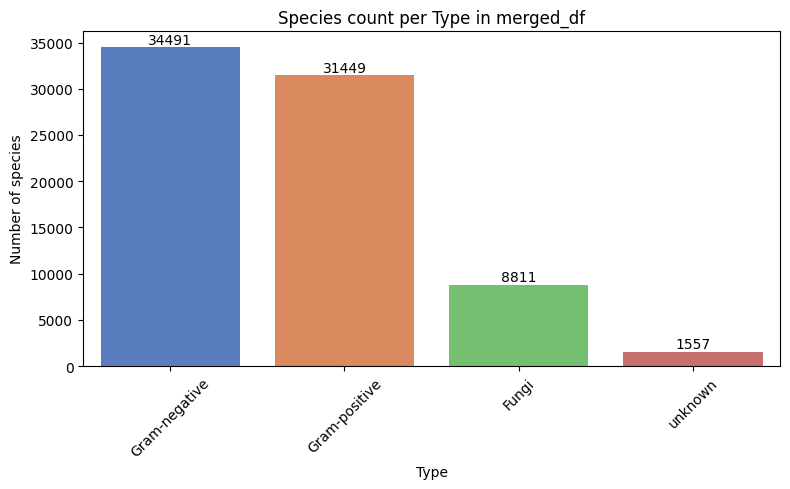

In [14]:
# 统计 merged_df['Type'] 各类型的种类个数并画直方图
import matplotlib.pyplot as plt
import seaborn as sns

type_counts = merged_df['Type'].value_counts().sort_values(ascending=False)
print(len(merged_df))
display(type_counts.to_frame(name='count'))
plt.figure(figsize=(8,5))
sns.barplot(x=type_counts.index, y=type_counts.values, palette='muted')
plt.ylabel('Number of species')
plt.xlabel('Type')
plt.title('Species count per Type in merged_df')
plt.xticks(rotation=45)
for i, v in enumerate(type_counts.values):
    plt.text(i, v + max(type_counts.values)*0.01, str(v), ha='center')
plt.tight_layout()
plt.show()


/tmp/ipykernel_2257420/2639669860.py:14: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  aggregated_df = merged_df.groupby(group_key).apply(aggregate_mic_values).reset_index()


聚合后的数据已保存到 aggregated_MIC_values.csv


,count
Type,
Gram-negative,24458
Gram-positive,24049
Fungi,6746
unknown,1335


/tmp/ipykernel_2257420/2639669860.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=type_counts.index, y=type_counts.values, palette='muted')


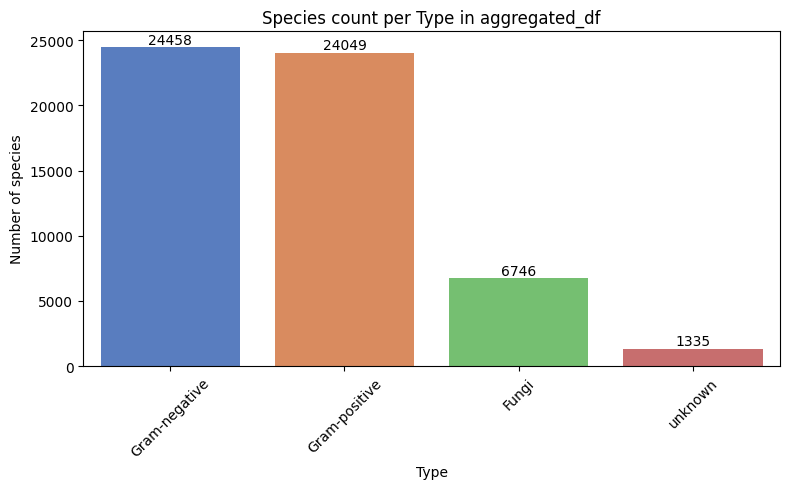

In [15]:
def aggregate_mic_values(group):
    return pd.Series({
        'Type': group['Type'].iloc[0],      
        'Tax_ID': group['Tax_ID'].iloc[0],
        'ID': group['ID'].iloc[0],
        'Median_MIC': group['log_MIC_Value(uM)'].median(),
        'Std_MIC': group['log_MIC_Value(uM)'].std(),
        'Max_MIC': group['log_MIC_Value(uM)'].max(),
        'Min_MIC': group['log_MIC_Value(uM)'].min(),
        'Count': group['log_MIC_Value(uM)'].count()
    })

group_key = ["Target_Species", "Sequence"]
aggregated_df = merged_df.groupby(group_key).apply(aggregate_mic_values).reset_index()
aggregated_df.to_csv("aggregated_MIC_values.csv", index=True)
print("聚合后的数据已保存到 aggregated_MIC_values.csv")

type_counts = aggregated_df['Type'].value_counts().sort_values(ascending=False)
display(type_counts.to_frame(name='count'))
plt.figure(figsize=(8,5))
sns.barplot(x=type_counts.index, y=type_counts.values, palette='muted')
plt.ylabel('Number of species')
plt.xlabel('Type')
plt.title('Species count per Type in aggregated_df')
plt.xticks(rotation=45)
for i, v in enumerate(type_counts.values):
    plt.text(i, v + max(type_counts.values)*0.01, str(v), ha='center')
plt.tight_layout()
plt.show()

In [16]:
merged_df.to_csv("total_MIC_values.csv", index=True)
# unknown 的可以扔掉
cleaned_merged_df = merged_df[merged_df['Type'] != 'unknown']
print(cleaned_merged_df['Type'].value_counts())
cleaned_merged_df.to_csv("cleaned_MIC_values.csv", index=True)

cleaned_aggregated_df = aggregated_df[aggregated_df['Type'] != 'unknown']
print(cleaned_aggregated_df['Type'].value_counts())
cleaned_aggregated_df.to_csv("cleaned_aggregated_MIC_values.csv", index=True)


Type
Gram-negative    34491
Gram-positive    31449
Fungi             8811
Name: count, dtype: int64
Type
Gram-negative    24458
Gram-positive    24049
Fungi             6746
Name: count, dtype: int64


In [17]:
# 对aggregated_df进行统计
aggregated_df['Std_MIC'].describe()


count    1.266500e+04
mean     3.026487e-01
std      2.789717e-01
min      1.355253e-20
25%      1.064302e-01
50%      2.128604e-01
75%      4.257207e-01
max      2.547041e+00
Name: Std_MIC, dtype: float64

In [18]:
quantiles = [0.1, 0.25, 0.5, 0.75, 0.9, 0.95, 0.99]
quantile_values = aggregated_df['Std_MIC'].quantile(quantiles)

# 2. 统计分布表
stats_table = pd.DataFrame({
    'Quantile': [f'{int(q*100)}%' for q in quantiles],
    'Std_MIC_Threshold': quantile_values.values
})

print("Std_MIC 分位数统计表：")
print(stats_table)

Std_MIC 分位数统计表：
  Quantile  Std_MIC_Threshold
0      10%           0.006860
1      25%           0.106430
2      50%           0.212860
3      75%           0.425721
4      90%           0.651116
5      95%           0.851441
6      99%           1.277162


/tmp/ipykernel_2257420/3729358892.py:80: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90, ha='right', fontsize=10)
/tmp/ipykernel_2257420/3729358892.py:80: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90, ha='right', fontsize=10)
/tmp/ipykernel_2257420/3729358892.py:80: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90, ha='right', fontsize=10)
/tmp/ipykernel_2257420/3729358892.py:80: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90, ha='right', fontsize=10)


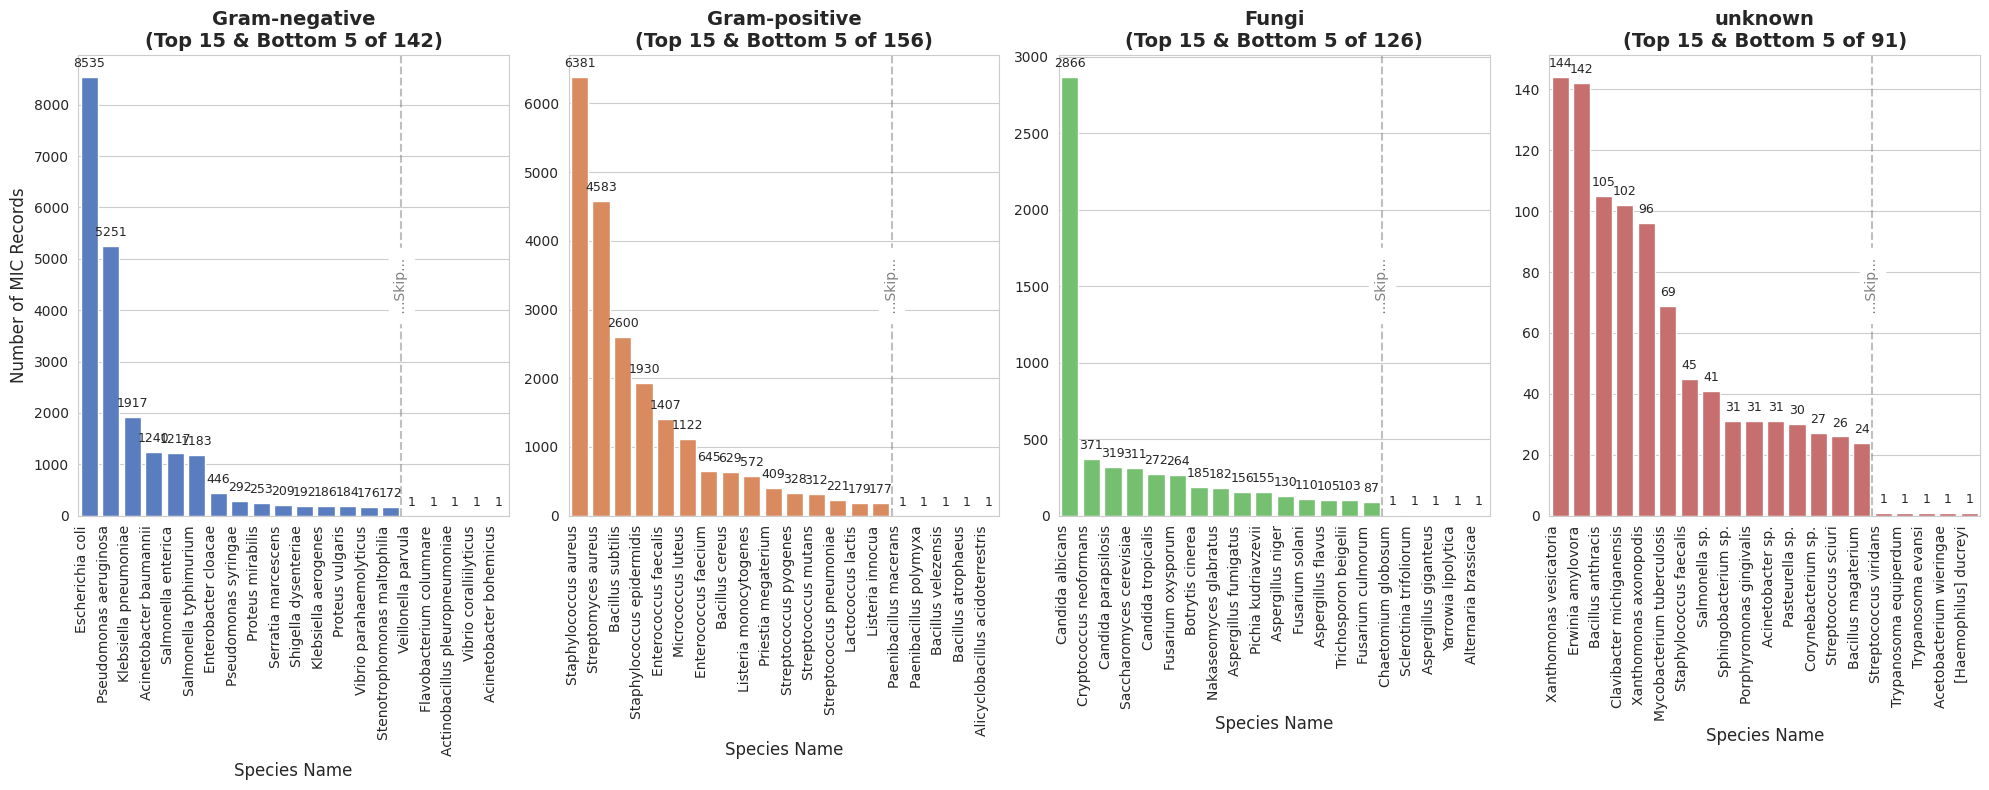

In [19]:

# ==========================================
# 1. 假设数据准备 (替换为你真实的 aggregated_df)
# ==========================================
# 你的 dataframe 应该至少包含: 'Type' (分类) 和 'species_name' (物种名)
# 这里的代码假设每一行是一条 MIC 记录
# 如果 aggregated_df 已经是统计好的数据，请跳过下面的 groupby 步骤
# ==========================================

def plot_top_bottom_species(df, type_col='Type', species_col='Target_Species', top_n=15, bottom_n=5):
    """
    df: 原始数据框
    type_col: 阴性/阳性/真菌 的列名
    species_col: 菌种名称的列名
    top_n: 显示最多的 n 个
    bottom_n: 显示最少的 n 个
    """
    
    # 1. 统计每个菌种的记录数 (MIC entries count)
    species_counts = df.groupby([type_col, species_col]).size().reset_index(name='record_count')
    
    # 定义分类顺序
    categories = ['Gram-negative', 'Gram-positive', 'Fungi', 'unknown']
    
    # 设置绘图风格
    sns.set_style("whitegrid")
    
    # 创建 4 个子图 (1行4列)
    fig, axes = plt.subplots(1, 4, figsize=(20, 8), sharey=False)
    
    palette = sns.color_palette('muted')
    
    for idx, cat in enumerate(categories):
        ax = axes[idx]
        
        # 筛选当前 Type 的数据
        subset = species_counts[species_counts[type_col] == cat]
        
        # 按记录数倒序排列
        subset = subset.sort_values(by='record_count', ascending=False)
        
        # --- 核心截断逻辑 ---
        total_species = len(subset)
        if total_species > (top_n + bottom_n):
            # 取头部和尾部
            head_df = subset.head(top_n)
            tail_df = subset.tail(bottom_n)
            
            # 插入一个“分割线”数据（可选，为了视觉区分）
            # 这里我们直接拼接，但在图中可以通过颜色区分
            plot_data = pd.concat([head_df, tail_df])
            title_suffix = f"(Top {top_n} & Bottom {bottom_n} of {total_species})"
        else:
            # 数据量少，直接全部显示
            plot_data = subset
            title_suffix = f"(All {total_species} species)"
        
        # --- 绘图 ---
        # 使用 Barplot
        # x=species, y=count
        bars = sns.barplot(
            data=plot_data, 
            x=species_col, 
            y='record_count', 
            ax=ax, 
            color=palette[idx] # 使用统一颜色，或者你可以根据头部尾部设不同颜色
        )
        
        # 设置标题和标签
        ax.set_title(f'{cat}\n{title_suffix}', fontsize=14, fontweight='bold')
        ax.set_xlabel('Species Name', fontsize=12)
        
        # 第一个图显示 Y 轴标签，其他的为了美观可以隐藏或保留
        if idx == 0:
            ax.set_ylabel('Number of MIC Records', fontsize=12)
        else:
            ax.set_ylabel('')
        
        # --- 调整 X 轴标签 ---
        # 旋转 90 度防止重叠，并右对齐
        ax.set_xticklabels(ax.get_xticklabels(), rotation=90, ha='right', fontsize=10)
        
        # --- 在柱子上标记数值 ---
        for p in bars.patches:
            height = p.get_height()
            if height > 0: # 避免空柱子报错
                ax.annotate(f'{int(height)}',
                            (p.get_x() + p.get_width() / 2., height),
                            ha='center', va='bottom', 
                            xytext=(0, 5), 
                            textcoords='offset points',
                            fontsize=9, rotation=0)

        # --- 视觉优化：给头部和尾部之间加一条虚线分隔 (如果发生了截断) ---
        if total_species > (top_n + bottom_n):
            # 在 Top N 和 Bottom N 之间画一条竖线
            ax.axvline(x=top_n - 0.5, color='gray', linestyle='--', alpha=0.5)
            ax.text(top_n - 0.5, ax.get_ylim()[1]*0.5, " ...Skip... ", 
                    rotation=90, ha='center', va='center', color='gray', backgroundcolor='white')

    plt.tight_layout()
    plt.show()

# ==========================================
# 运行代码
# ==========================================
# 假设你的 aggregated_df 中：
# 'Type' 列存储分类 (Gram-negative, Gram-positive, Fungi)
# 'species' 列存储具体的菌名 (如 Escherichia coli)
# 如果列名不同，请修改参数: type_col 和 species_col

# 示例调用：
plot_top_bottom_species(aggregated_df, type_col='Type', species_col='Target_Species', top_n=15, bottom_n=5)

In [20]:
# check aggregated_MIC_values 有没有出现同一个Tax_ID对应不同Target_Species的情况
aggregated_df = pd.read_csv('aggregated_MIC_values.csv', dtype={'Tax_ID':str}, index_col=0)

# 聚合Tax_ID，查看每个Tax_ID对应的Target_Species的唯一值
tax_id_species_mapping = aggregated_df.groupby('Tax_ID')['Target_Species'].nunique()

# 查看是否存在一个Tax_ID对应多个不同Target_Species的情况
multi_species_tax_ids = tax_id_species_mapping[tax_id_species_mapping > 1]

print(f"总Tax_ID数: {len(tax_id_species_mapping)}")
print(f"有多个Target_Species对应的Tax_ID数: {len(multi_species_tax_ids)}")
print()

if len(multi_species_tax_ids) == 0:
    print("✓ 结论：不存在同一个Tax_ID对应不同Target_Species的情况")
else:
    print(f"✗ 发现 {len(multi_species_tax_ids)} 个Tax_ID对应多个Target_Species:")
    print(multi_species_tax_ids.sort_values(ascending=False))
    print()
    print("具体映射关系:")
    for tax_id in multi_species_tax_ids.index:
        species_list = aggregated_df[aggregated_df['Tax_ID'] == tax_id]['Target_Species'].unique()
        print(f"  Tax_ID {tax_id}: {species_list}")

总Tax_ID数: 515
有多个Target_Species对应的Tax_ID数: 0

✓ 结论：不存在同一个Tax_ID对应不同Target_Species的情况


In [21]:
# check total_MIC_values 有没有出现同一个Tax_ID对应不同Target_Species的情况
aggregated_df = pd.read_csv('total_MIC_values.csv', dtype={'Tax_ID':str}, index_col=0)

# 聚合Tax_ID，查看每个Tax_ID对应的Target_Species的唯一值
tax_id_species_mapping = aggregated_df.groupby('Tax_ID')['Target_Species'].nunique()

# 查看是否存在一个Tax_ID对应多个不同Target_Species的情况
multi_species_tax_ids = tax_id_species_mapping[tax_id_species_mapping > 1]

print(f"总Tax_ID数: {len(tax_id_species_mapping)}")
print(f"有多个Target_Species对应的Tax_ID数: {len(multi_species_tax_ids)}")
print()

if len(multi_species_tax_ids) == 0:
    print("✓ 结论：不存在同一个Tax_ID对应不同Target_Species的情况")
else:
    print(f"✗ 发现 {len(multi_species_tax_ids)} 个Tax_ID对应多个Target_Species:")
    print(multi_species_tax_ids.sort_values(ascending=False))
    print()
    print("具体映射关系:")
    for tax_id in multi_species_tax_ids.index:
        species_list = aggregated_df[aggregated_df['Tax_ID'] == tax_id]['Target_Species'].unique()
        print(f"  Tax_ID {tax_id}: {species_list}")

总Tax_ID数: 515
有多个Target_Species对应的Tax_ID数: 0

✓ 结论：不存在同一个Tax_ID对应不同Target_Species的情况


/tmp/ipykernel_2257420/2009755716.py:2: DtypeWarning: Columns (4) have mixed types. Specify dtype option on import or set low_memory=False.
  aggregated_df = pd.read_csv('total_MIC_values.csv', dtype={'Tax_ID':str}, index_col=0)


/tmp/ipykernel_1872686/16200790.py:24: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cleaned_aggregated_df


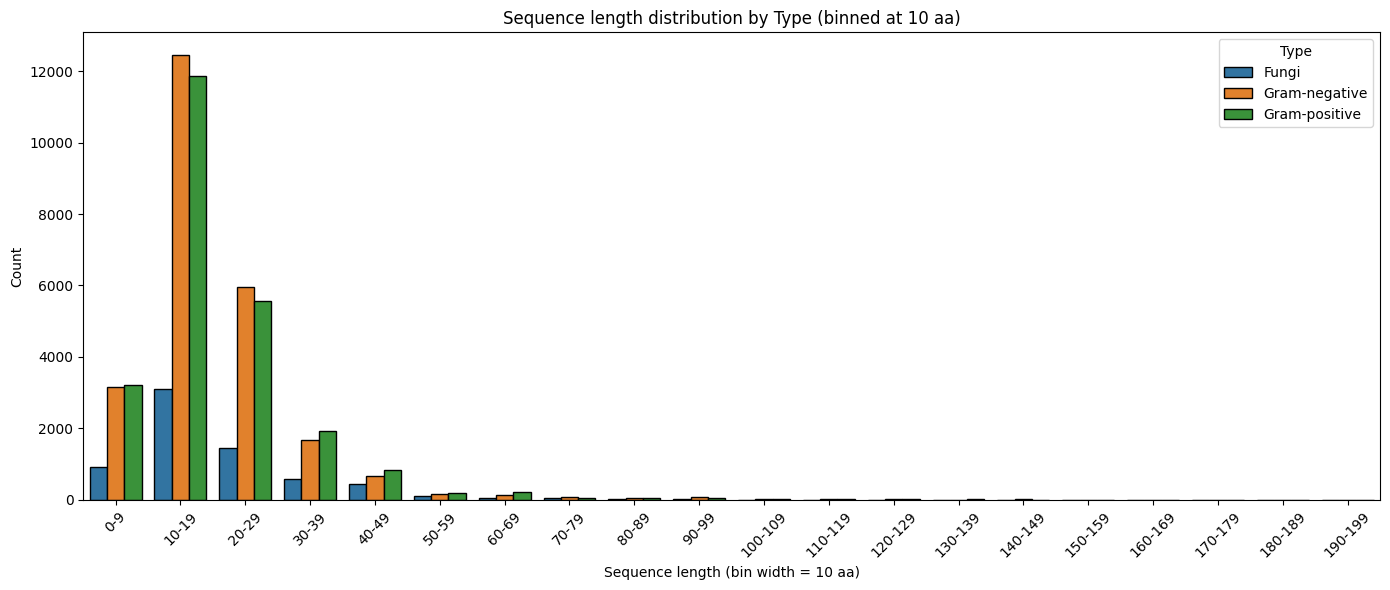

In [6]:
# 对cleaned_aggreted_MIC_values.csv 文件统计序列长度分布，按Type统计并按10 aa分箱
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

cleaned_aggregated_df = pd.read_csv('cleaned_aggregated_MIC_values.csv', dtype={'Tax_ID': str}, index_col=0)
cleaned_aggregated_df['Sequence_Length'] = cleaned_aggregated_df['Sequence'].astype(str).str.len()

# 10 aa 为一个 bin
max_len = int(cleaned_aggregated_df['Sequence_Length'].max())
bins = list(range(0, (max_len // 10 + 2) * 10, 10))
labels = [f"{b}-{b+9}" for b in bins[:-1]]

cleaned_aggregated_df['Length_Bin'] = pd.cut(
    cleaned_aggregated_df['Sequence_Length'],
    bins=bins,
    labels=labels,
    right=True,
    include_lowest=True,
)

counts = (
    cleaned_aggregated_df
    .groupby(['Type', 'Length_Bin'])
    .size()
    .reset_index(name='count')
)

plt.figure(figsize=(14, 6))
sns.barplot(
    data=counts,
    x='Length_Bin',
    y='count',
    hue='Type',
    edgecolor='black',
)
plt.xticks(rotation=45)
plt.xlabel('Sequence length (bin width = 10 aa)')
plt.ylabel('Count')
plt.title('Sequence length distribution by Type (binned at 10 aa)')
plt.tight_layout()
plt.show()
